# The scoreboard

### Every method, every house dataset, one table, and why the order keeps changing

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How to build one evaluation harness that produces every cell of a comparison table identically, how to tell which rows of that table are separated by the data and which are a coin flip, and how to measure the properties of a dataset that decide which family of model wins on it |
| **You should already know** | [Cross-validation](../../01-foundations/04-cross-validation/), and roughly what each method in the book does: [logistic regression](../../03-classification/01-logistic-regression/), [k-NN](../../03-classification/02-k-nearest-neighbours/), [naive Bayes](../../03-classification/03-naive-bayes/), [SVMs](../../03-classification/05-support-vector-machines/), [trees](../../03-classification/06-decision-trees/), [random forests](../../04-ensembles/02-random-forest/), [gradient boosting](../../04-ensembles/05-gradient-boosting/), [MLPs](../../07-neural-networks/02-mlp-and-backpropagation/) |
| **Datasets** | UCI Dry Bean, Breast Cancer Wisconsin, California Housing, UCI Bike Sharing |
| **Runtime** | Under two minutes on a laptop CPU. The four `done in` lines account for most of it |
| **Next** | [12-02 Interpreting models](../02-interpreting-models/) |

---

## 1. Why this chapter exists

Every notebook in this book used the same handful of datasets. That was not
laziness. It was so that this chapter could exist.

When a tutorial tells you gradient boosting scored 0.94 and another tells you an
SVM scored 0.91, you have learned nothing, because the two numbers came from
different data, different splits, different preprocessing and probably different
amounts of tuning. Put them on the same data with the same folds and the same
scaling rule, and the difference means something.

It might still mean nothing. That is the second half of this chapter and the
part that most comparison tables skip. A scoreboard invites you to read it
top to bottom as an ordering, and on some of these columns the ordering is an
artefact of which rows landed in which fold. So every table below is printed
next to its fold-to-fold standard deviation, and every ranking claim I make is
checked against that spread before I make it.

Two warnings before the numbers.

**Nothing here is tuned.** Every method uses a sensible default setting, stated
in the code. A tuned SVM would beat an untuned one, and the ordering would move.
What you are reading is the ordering you get when you reach for a method and run
it, which is what most people actually do first. [Chapter
01-09](../../01-foundations/09-hyperparameter-tuning/) is where tuning gets its
own budget.

**Every dataset is capped at six thousand rows.** Dry bean, California housing
and bike sharing are all larger than that; each is randomly subsampled down so
the whole notebook finishes in minutes rather than an afternoon, and so that an
RBF kernel SVM, which costs roughly the square of the row count, stays
affordable. Absolute scores would move up a little on the full data. The
ordering, in my experience, mostly does not.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The harness

One function, `score`, takes an estimator and a dataset and returns a
cross-validated result. Every cell in every table below is produced by that
function and nothing else, so when two rows differ, the estimator is the only
thing that differed.

The rules it fixes:

Five folds, shuffled, seed zero. Stratified for classification so the rare bean
varieties appear in every fold, plain for regression.

Scaling lives *inside* a pipeline, so the scaler is refitted on each training
fold and never sees the fold it is scored on. Scaling is applied to every
method, including the trees, where it makes no difference at all: a decision
tree splits on order, and standardising a column does not change the order.
Keeping it uniform is worth more than saving a microsecond.

For the regression side the *target* is standardised too, and un-standardised
again before scoring. That is there so a penalty strength like ridge's `alpha`
means the same thing on a target measured in hundreds of thousands of dollars as
on one measured in bicycles per hour. Without it, the same alpha is heavy
regularisation on one dataset and no regularisation on the other, and the two
columns stop being comparable. R-squared is unaffected by the transform for
every unpenalised model.

Folds run in parallel, five at a time, but each estimator is pinned to a single
thread. That is so the fit-time column measures something: a random forest given
eight cores would look artificially cheap next to an SVM that cannot use them.

In [2]:
import time
import warnings
from dataclasses import dataclass

from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import (KFold, StratifiedKFold, cross_val_score,
                                     cross_validate)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Untuned defaults on four different datasets will not all converge. That is part
# of what "untuned" means, and the warnings would drown the output.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

CAP = 6000        # rows kept per dataset, so the whole notebook runs in minutes
N_FOLDS = 5
CV_JOBS = 5       # one process per fold; estimators stay single-threaded


@dataclass
class Task:
    """A dataset plus what kind of problem it is. The harness needs both."""
    name: str
    kind: str          # "classification" or "regression"
    X: np.ndarray
    y: np.ndarray
    columns: list


def load_task(name, kind, loader):
    X, y = loader()
    X = X.select_dtypes(include="number")
    if len(X) > CAP:
        idx = np.random.default_rng(SEED).permutation(len(X))[:CAP]
        X, y = X.iloc[idx], y.iloc[idx]
    y = y.to_numpy()
    if kind == "classification":
        # Class names become integer codes here rather than inside each estimator.
        # Accuracy does not care what a class is called, so this changes no score,
        # and it means every classifier is handed a target of the same dtype.
        y = np.unique(y, return_inverse=True)[1]
    return Task(name, kind, X.to_numpy(dtype=float), y, list(X.columns))


TASKS = [
    load_task("dry bean", "classification", datasets.dry_bean),
    load_task("breast cancer", "classification", datasets.breast_cancer),
    load_task("california housing", "regression", datasets.california_housing),
    load_task("bike sharing", "regression", datasets.bike_sharing),
]

for task in TASKS:
    labels = len(np.unique(task.y)) if task.kind == "classification" else None
    extra = f", {labels} classes" if labels else ""
    print(f"{task.name:<19} {task.kind:<15} {task.X.shape[0]:>5} rows x "
          f"{task.X.shape[1]:>2} columns{extra}")

dry bean            classification   6000 rows x 16 columns, 7 classes
breast cancer       classification    569 rows x 30 columns, 2 classes
california housing  regression       6000 rows x  8 columns
bike sharing        regression       6000 rows x 12 columns


In [3]:
def wrap(model, kind):
    """Put the estimator behind the same preprocessing every time.

    Scaling is refitted per fold inside the pipeline, which is the only way to
    keep the validation fold genuinely unseen.
    """
    steps = make_pipeline(StandardScaler(), model)
    if kind == "regression":
        # Standardise y as well, so alpha means the same thing on both targets.
        return TransformedTargetRegressor(regressor=steps, transformer=StandardScaler())
    return steps


def score(model, task):
    """One cell of the scoreboard: cross-validated quality, spread, and cost."""
    if task.kind == "classification":
        folds = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
        metric = "accuracy"
    else:
        folds = KFold(N_FOLDS, shuffle=True, random_state=SEED)
        metric = "r2"

    out = cross_validate(wrap(model, task.kind), task.X, task.y,
                         cv=folds, scoring=metric, n_jobs=CV_JOBS)
    return {"score": out["test_score"].mean(),
            "sd": out["test_score"].std(),
            "fit_seconds": out["fit_time"].mean()}


def run(models, kinds):
    """Every model against every task of the matching kind."""
    rows = []
    for task in TASKS:
        if task.kind not in kinds:
            continue
        started = time.perf_counter()
        for name, build in models.items():
            rows.append({"method": name, "dataset": task.name,
                         **score(build(), task)})
        print(f"{task.name:<19} done in {time.perf_counter() - started:5.1f} s")
    return pd.DataFrame(rows)

### A yardstick for the noise

`score` returns a standard deviation as well as a mean, and that second number
decides whether the first one can be ranked.

The obvious move is to divide the fold standard deviation by the square root of
the fold count and call it a standard error. Do not. The five fold scores are not
five independent measurements: every pair of training folds shares three fifths
of its rows, so the scores are positively correlated and the naive standard error
comes out too small. Bengio and Grandvalet showed in 2004 that there is no
unbiased estimator of the variance of k-fold cross-validation at all, and that
the naive one is optimistic. Given that, I use the fold standard deviation itself
as the yardstick, which is the conservative end of the range.

The rule for the rest of the notebook: a method whose gap to the leader is less
than about one pooled fold standard deviation has not lost to it. It is in the
same group, and the ordering between them is which rows fell in which fold.
`tie_group` prints that group so I cannot quietly forget it while writing prose.

In [4]:
def tie_group(board, sds, dataset, anchor=None):
    """Methods on `dataset` this experiment cannot separate from `anchor`.

    The gap is measured in pooled fold standard deviations, so a method with a
    noisy score needs a bigger gap before it counts as beaten. Under 1.0 means the
    two are one group; over about 2 is where I am willing to call a winner.
    """
    column, spread = board[dataset], sds[dataset]
    order = list(column.sort_values(ascending=False).index)
    anchor = anchor or order[0]
    pooled = np.sqrt((spread[anchor] ** 2 + spread ** 2) / 2).clip(lower=1e-12)
    frame = pd.DataFrame({"score": column,
                          "gap": column[anchor] - column,
                          "gap / sd": (column[anchor] - column) / pooled}).loc[order]
    tied = frame[frame["gap / sd"].abs() < 1.0]
    print(f"\n{dataset}: measured against {anchor}")
    print(frame.round(4).to_string())
    print(f"  within one pooled fold sd: {len(tied)} of {len(frame)}"
          f"  ->  {', '.join(tied.index)}")
    return tied


def tie_report(board, sds, names):
    """Run the test twice per dataset: once from the leader, once from second place.

    A rank table is built from the whole column, not only from the top of it, so a
    tie between second and sixth invents four places just as happily as a tie at
    the top invents one.
    """
    leaders = {}
    for name in names:
        leaders[name] = tie_group(board, sds, name)
        runner_up = list(board[name].sort_values(ascending=False).index)[1]
        tie_group(board, sds, name, anchor=runner_up)
    return leaders

## 3. The classification table

Ten methods, from the cheapest linear model to a small neural network. The
settings are the ones a person types without thinking: a hundred and fifty trees
in the forests, ten neighbours for k-NN, a two-layer MLP with a hard cap on
epochs and early stopping.

`n_jobs=1` everywhere is deliberate, for the timing column.

In [5]:
from sklearn.ensemble import (ExtraTreesClassifier, GradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

CLASSIFIERS = {
    "logistic regression": lambda: LogisticRegression(max_iter=3000),
    "k-NN (k=10)":         lambda: KNeighborsClassifier(n_neighbors=10, n_jobs=1),
    "naive Bayes":         lambda: GaussianNB(),
    "linear SVM":          lambda: LinearSVC(C=1.0, max_iter=8000, random_state=SEED),
    "RBF SVM":             lambda: SVC(C=1.0, gamma="scale", cache_size=500,
                                       random_state=SEED),
    "decision tree":       lambda: DecisionTreeClassifier(random_state=SEED),
    "random forest":       lambda: RandomForestClassifier(n_estimators=150, n_jobs=1,
                                                          random_state=SEED),
    "extra trees":         lambda: ExtraTreesClassifier(n_estimators=150, n_jobs=1,
                                                        random_state=SEED),
    "gradient boosting":   lambda: GradientBoostingClassifier(n_estimators=100,
                                                              random_state=SEED),
    "MLP (64, 32)":        lambda: MLPClassifier(hidden_layer_sizes=(64, 32),
                                                 max_iter=300, early_stopping=True,
                                                 n_iter_no_change=10, random_state=SEED),
}

clf = run(CLASSIFIERS, {"classification"})

CLF_SETS = ["dry bean", "breast cancer"]
clf_score = clf.pivot(index="method", columns="dataset",
                      values="score").loc[list(CLASSIFIERS), CLF_SETS]
clf_time = clf.pivot(index="method", columns="dataset",
                     values="fit_seconds").loc[list(CLASSIFIERS), CLF_SETS]
clf_sd = clf.pivot(index="method", columns="dataset",
                   values="sd").loc[list(CLASSIFIERS), CLF_SETS]

print("\nmean accuracy over 5 folds")
print(clf_score.round(4).to_string())
print("\nstandard deviation across folds")
print(clf_sd.round(4).to_string())

dry bean            done in  40.1 s


breast cancer       done in   1.8 s

mean accuracy over 5 folds
dataset              dry bean  breast cancer
method                                      
logistic regression    0.9235         0.9789
k-NN (k=10)            0.9217         0.9666
naive Bayes            0.8952         0.9297
linear SVM             0.9180         0.9684
RBF SVM                0.9308         0.9771
decision tree          0.8930         0.9262
random forest          0.9205         0.9596
extra trees            0.9120         0.9684
gradient boosting      0.9233         0.9649
MLP (64, 32)           0.9248         0.9385

standard deviation across folds
dataset              dry bean  breast cancer
method                                      
logistic regression    0.0021         0.0142
k-NN (k=10)            0.0042         0.0170
naive Bayes            0.0023         0.0124
linear SVM             0.0017         0.0119
RBF SVM                0.0040         0.0070
decision tree          0.0052         0.0218
ran

winner per dataset
  dry bean        RBF SVM              0.9308   (0.23 s per fit)
  breast cancer   logistic regression  0.9789   (0.01 s per fit)


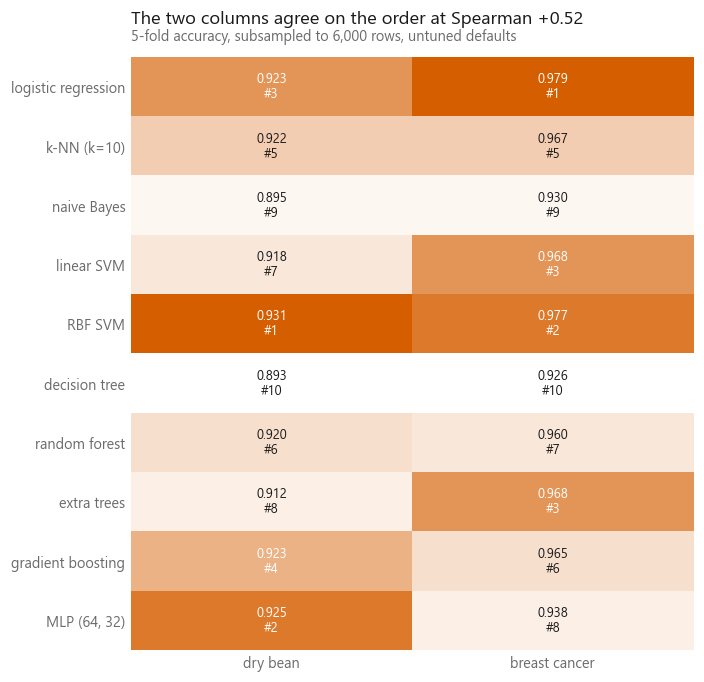

In [6]:
from matplotlib.colors import LinearSegmentedColormap

# White for last place, the highlight colour for first, so the eye reads a column
# as an ordering rather than as a set of unrelated numbers.
BOARD = LinearSegmentedColormap.from_list("board", ["#ffffff", "#f7dcc8", style.HIGHLIGHT])


def draw_board(ax, table, fmt="{:.3f}"):
    """A heatmap shaded by rank within each column, annotated with the raw score."""
    ranks = table.rank(ascending=False, axis=0, method="min")
    shade = (1 - (ranks - 1) / (len(table) - 1)).to_numpy()
    ax.imshow(shade, cmap=BOARD, vmin=0, vmax=1, aspect="auto")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, fmt.format(table.iat[i, j]) + f"\n#{int(ranks.iat[i, j])}",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if shade[i, j] > 0.62 else style.INK)
    ax.set_xticks(range(table.shape[1]), list(table.columns))
    ax.set_yticks(range(table.shape[0]), list(table.index))
    ax.tick_params(length=0)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ranks


fig, ax = plt.subplots(figsize=(6.6, 7.0))
clf_rank = draw_board(ax, clf_score)
agreement = clf_rank[CLF_SETS[0]].corr(clf_rank[CLF_SETS[1]], method="spearman")
style.title(ax, f"The two columns agree on the order at Spearman {agreement:+.2f}",
            "5-fold accuracy, subsampled to 6,000 rows, untuned defaults")
style.save(fig, FIG / "fig-01-classification-scoreboard.png")

print("winner per dataset")
for name in CLF_SETS:
    top = clf_score[name].idxmax()
    print(f"  {name:<15} {top:<20} {clf_score.loc[top, name]:.4f}   "
          f"({clf_time.loc[top, name]:.2f} s per fit)")

In [7]:
clf_tied = tie_report(clf_score, clf_sd, CLF_SETS)


dry bean: measured against RBF SVM
                      score     gap  gap / sd
method                                       
RBF SVM              0.9308  0.0000    0.0000
MLP (64, 32)         0.9248  0.0060    1.2443
logistic regression  0.9235  0.0073    2.3126
gradient boosting    0.9233  0.0075    2.1096
k-NN (k=10)          0.9217  0.0092    2.2269
random forest        0.9205  0.0103    1.9979
linear SVM           0.9180  0.0128    4.1882
extra trees          0.9120  0.0188    5.0136
naive Bayes          0.8952  0.0357   10.9492
decision tree        0.8930  0.0378    8.1383
  within one pooled fold sd: 1 of 10  ->  RBF SVM

dry bean: measured against MLP (64, 32)
                      score     gap  gap / sd
method                                       
RBF SVM              0.9308 -0.0060   -1.2443
MLP (64, 32)         0.9248  0.0000    0.0000
logistic regression  0.9235  0.0013    0.3190
gradient boosting    0.9233  0.0015    0.3349
k-NN (k=10)          0.9217  0.0032    0.6416

The heatmap paints a rank on every cell. The tables above are the correction to
it, and the two columns fail in different places.

Breast cancer fails at the top, for a reason that is arithmetic rather than
statistical. It has 569 rows, so a fold holds about a fifth of them, and one extra
mistake in a fold moves that fold's accuracy by nearly a percentage point. The
fold standard deviations are on that scale and so are most of the gaps between
methods. Read the `gap / sd` column against the leader: more than half the field
sits under 1.0. Logistic regression, both SVMs, k-NN, the extra trees and
gradient boosting are one group, and the order inside it is which patients landed
in which fold. What this column does separate is the bottom three, and that
separation has a mechanism, which section 5 gets to.

Dry bean has ten times the rows, so its fold standard deviations are smaller by
roughly the square root of that, and the RBF SVM's lead over the field survives.
The failure there is one row down. Anchor the same test on the runner-up and the
block underneath the SVM collapses into a single group. That block is the one
that goes on to produce five different ranks in the family table at the end of
this notebook, out of a spread of accuracy you would not notice.

So the practical consequence. If two methods have a `gap / sd` under one, choose
between them on something else: fit time, memory, whether you can explain it to a
person, whether the library API is stable. Those differences are real. The
accuracy difference is not.

## 4. The regression table

Eight methods this time. There is no naive Bayes or SVM equivalent worth
including, and the linear family splits into three: plain, ridge, and lasso.
Scoring is R-squared, so higher is better and the columns read the same
direction as the classification ones.

In [8]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor

REGRESSORS = {
    "linear regression": lambda: LinearRegression(),
    "ridge":             lambda: Ridge(alpha=1.0),
    "lasso":             lambda: Lasso(alpha=0.1, max_iter=10000),
    "k-NN (k=10)":       lambda: KNeighborsRegressor(n_neighbors=10, n_jobs=1),
    "decision tree":     lambda: DecisionTreeRegressor(random_state=SEED),
    "random forest":     lambda: RandomForestRegressor(n_estimators=150, n_jobs=1,
                                                       random_state=SEED),
    "gradient boosting": lambda: GradientBoostingRegressor(n_estimators=150,
                                                           random_state=SEED),
    "MLP (64, 32)":      lambda: MLPRegressor(hidden_layer_sizes=(64, 32),
                                              max_iter=300, early_stopping=True,
                                              n_iter_no_change=10, random_state=SEED),
}

reg = run(REGRESSORS, {"regression"})

REG_SETS = ["california housing", "bike sharing"]
reg_score = reg.pivot(index="method", columns="dataset",
                      values="score").loc[list(REGRESSORS), REG_SETS]
reg_time = reg.pivot(index="method", columns="dataset",
                     values="fit_seconds").loc[list(REGRESSORS), REG_SETS]
reg_sd = reg.pivot(index="method", columns="dataset",
                   values="sd").loc[list(REGRESSORS), REG_SETS]

print("\nmean R-squared over 5 folds")
print(reg_score.round(4).to_string())
print("\nstandard deviation across folds")
print(reg_sd.round(4).to_string())

california housing  done in   9.5 s


bike sharing        done in   7.1 s

mean R-squared over 5 folds
dataset            california housing  bike sharing
method                                             
linear regression              0.6439        0.3827
ridge                          0.6439        0.3827
lasso                          0.5254        0.3412
k-NN (k=10)                    0.7242        0.5337
decision tree                  0.5382        0.8565
random forest                  0.7759        0.9243
gradient boosting              0.7916        0.8704
MLP (64, 32)                   0.7738        0.9088

standard deviation across folds
dataset            california housing  bike sharing
method                                             
linear regression              0.0373        0.0051
ridge                          0.0372        0.0051
lasso                          0.0185        0.0067
k-NN (k=10)                    0.0095        0.0083
decision tree                  0.0378        0.0125
random forest     

winner per dataset
  california housing  gradient boosting    0.7916   (1.86 s per fit)
  bike sharing        random forest        0.9243   (3.07 s per fit)

linear family, best of the three
  california housing  0.6439   (gap to the winner: +0.1477)
  bike sharing        0.3827   (gap to the winner: +0.5417)

inside the linear family
  california housing  ridge minus plain +0.00001   lasso minus ridge -0.1184
  bike sharing        ridge minus plain +0.00000   lasso minus ridge -0.0414


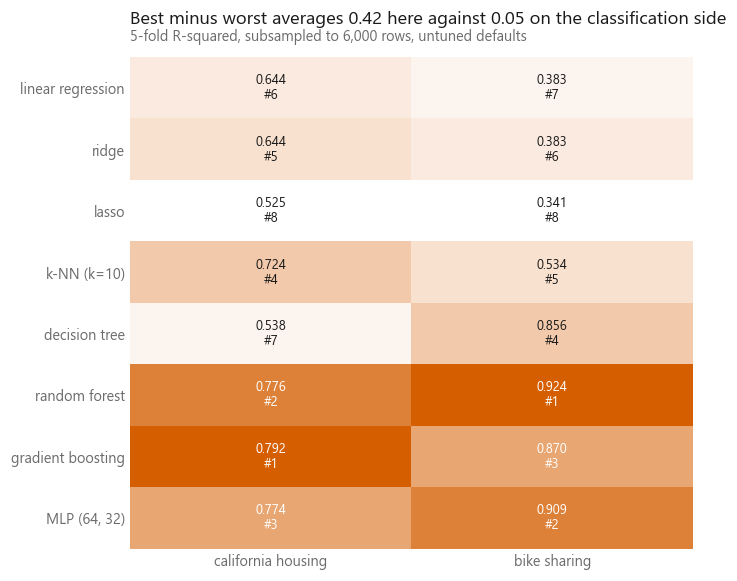

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 5.8))
reg_rank = draw_board(ax, reg_score)
reg_span = float((reg_score.max() - reg_score.min()).mean())
clf_span = float((clf_score.max() - clf_score.min()).mean())
style.title(ax, f"Best minus worst averages {reg_span:.2f} here against "
                f"{clf_span:.2f} on the classification side",
            "5-fold R-squared, subsampled to 6,000 rows, untuned defaults")
style.save(fig, FIG / "fig-02-regression-scoreboard.png")

print("winner per dataset")
for name in REG_SETS:
    top = reg_score[name].idxmax()
    print(f"  {name:<19} {top:<20} {reg_score.loc[top, name]:.4f}   "
          f"({reg_time.loc[top, name]:.2f} s per fit)")

print("\nlinear family, best of the three")
for name in REG_SETS:
    linear_best = reg_score.loc[["linear regression", "ridge", "lasso"], name].max()
    print(f"  {name:<19} {linear_best:.4f}   "
          f"(gap to the winner: {reg_score[name].max() - linear_best:+.4f})")

print("\ninside the linear family")
for name in REG_SETS:
    print(f"  {name:<19} ridge minus plain "
          f"{reg_score.loc['ridge', name] - reg_score.loc['linear regression', name]:+.5f}"
          f"   lasso minus ridge "
          f"{reg_score.loc['lasso', name] - reg_score.loc['ridge', name]:+.4f}")

In [10]:
reg_tied = tie_report(reg_score, reg_sd, REG_SETS)


california housing: measured against gradient boosting
                    score     gap  gap / sd
method                                     
gradient boosting  0.7916  0.0000    0.0000
random forest      0.7759  0.0158    1.2027
MLP (64, 32)       0.7738  0.0178    1.2073
k-NN (k=10)        0.7242  0.0674    5.5256
ridge              0.6439  0.1477    5.2319
linear regression  0.6439  0.1478    5.2270
decision tree      0.5382  0.2534    8.8522
lasso              0.5254  0.2662   16.0324
  within one pooled fold sd: 1 of 8  ->  gradient boosting

california housing: measured against random forest
                    score     gap  gap / sd
method                                     
gradient boosting  0.7916 -0.0158   -1.2027
random forest      0.7759  0.0000    0.0000
MLP (64, 32)       0.7738  0.0020    0.1517
k-NN (k=10)        0.7242  0.0516    4.8717
ridge              0.6439  0.1320    4.7846
linear regression  0.6439  0.1320    4.7799
decision tree      0.5382  0.2377    8.49

I expected the regression columns to separate the families more clearly than the
classification ones, and the `gap / sd` numbers say they do. The reason is not
that R-squared is a better metric. It is that these two targets are genuinely
harder to fit than a seven-way bean shape problem, so the spread between a method
that can represent the target and one that cannot is enormous compared with the
spread between folds.

Three things in this table are worth stopping on.

**Ridge and plain linear regression print the same score.** They should. Alpha is
1 against six thousand standardised rows, so the penalty is a rounding error next
to the sum of squares it is added to, and ridge converges on the ordinary
least-squares solution. Ridge earns its keep when rows are scarce or columns are
collinear, which is the setting [chapter
02-04](../../02-regression/04-ridge-regression/) builds. It is not this setting.

**Lasso is the worst regressor on California housing**, below a single decision
tree, and that is the same story read the other way. Alpha of 0.1 on a
standardised target is heavy L1, so it zeroes columns that were carrying signal.
A penalty strength is not a property of a method, it is a property of a method
plus a dataset, which is exactly why the target is standardised in the harness
and exactly why untuned comparisons need this caveat printed next to them.

**First place on California housing is still soft.** Gradient boosting's lead
over the random forest only just clears the one-standard-deviation bar, and the
random forest and the MLP behind it are a straight tie. On bike sharing the top
two clear that bar by a wide margin, which makes it the one dataset here where I
would read the ordering at the top and believe it.

### What it cost

A model that wins by less than a fold standard deviation and costs fifty times as
much to fit has not won anything. Here is quality against fitting time on the two
largest datasets.

cheapest method within 0.01 of the best, per dataset
  dry bean            best RBF SVM              0.9308 in   0.23 s
                      good k-NN (k=10)          0.9217 in   0.01 s   (35x cheaper, -0.0092)
  breast cancer       best logistic regression  0.9789 in   0.01 s
                      good RBF SVM              0.9771 in   0.01 s   (1x cheaper, -0.0018)
  california housing  best gradient boosting    0.7916 in   1.86 s
                      good gradient boosting    0.7916 in   1.86 s   (1x cheaper, +0.0000)
  bike sharing        best random forest        0.9243 in   3.07 s
                      good random forest        0.9243 in   3.07 s   (1x cheaper, +0.0000)

cheapest method inside the leader's tie group
  dry bean            1 tied, cheapest RBF SVM              0.9308 in  0.2276 s vs leader  0.2276 s
  breast cancer       6 tied, cheapest k-NN (k=10)          0.9666 in  0.0033 s vs leader  0.0099 s
  california housing  1 tied, cheapest gradient boosting    0.7916 

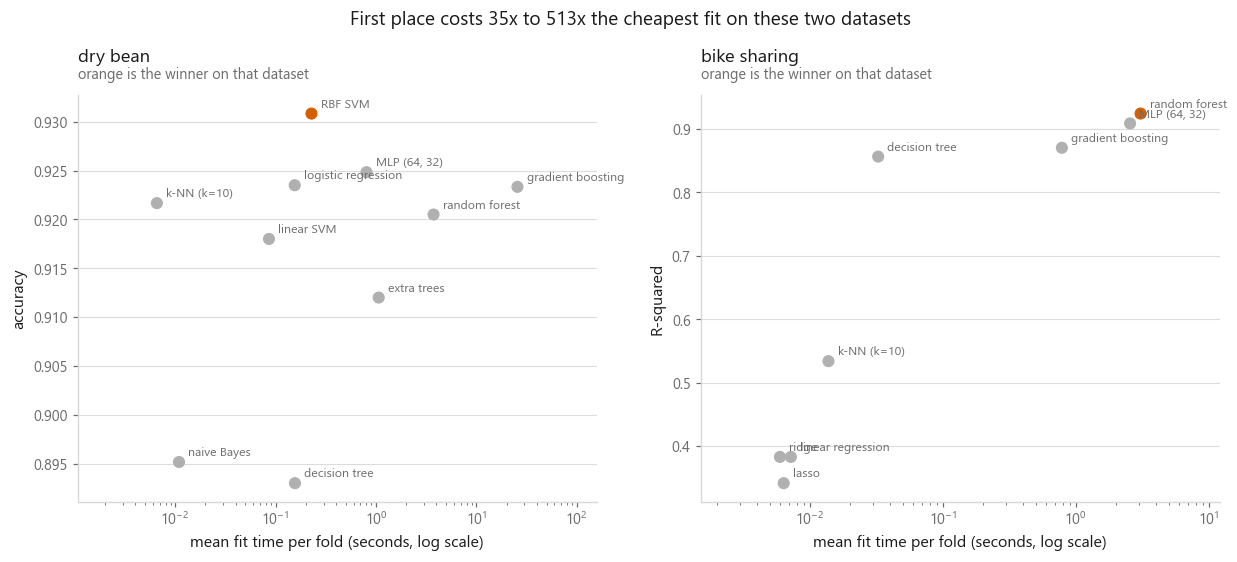

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

panels = [(axes[0], clf[clf["dataset"] == "dry bean"], "dry bean", "accuracy"),
          (axes[1], reg[reg["dataset"] == "bike sharing"], "bike sharing", "R-squared")]

for ax, frame, title_name, ylabel in panels:
    best = frame["score"].max()
    colours = [style.HIGHLIGHT if s == best else style.NEUTRAL for s in frame["score"]]
    ax.scatter(frame["fit_seconds"], frame["score"], c=colours, s=52, zorder=3)
    for row in frame.itertuples():
        ax.annotate(row.method, (row.fit_seconds, row.score), xytext=(6, 4),
                    textcoords="offset points", fontsize=8, color=style.MUTED)
    ax.set_xscale("log")
    ax.set_xlabel("mean fit time per fold (seconds, log scale)")
    ax.set_ylabel(ylabel)
    ax.margins(x=0.22)
    style.title(ax, title_name, "orange is the winner on that dataset")

cost_ratios = []
for frame in (clf[clf["dataset"] == "dry bean"], reg[reg["dataset"] == "bike sharing"]):
    cost_ratios.append(frame.loc[frame["score"].idxmax(), "fit_seconds"]
                       / max(frame["fit_seconds"].min(), 1e-9))
fig.suptitle(f"First place costs {min(cost_ratios):.0f}x to {max(cost_ratios):.0f}x "
             f"the cheapest fit on these two datasets",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-quality-against-time.png")

results = pd.concat([clf, reg], ignore_index=True)

print("cheapest method within 0.01 of the best, per dataset")
for task in TASKS:
    frame = results[results["dataset"] == task.name]
    best_row = frame.loc[frame["score"].idxmax()]
    close = frame[frame["score"] >= best_row["score"] - 0.01]
    cheap = close.loc[close["fit_seconds"].idxmin()]
    print(f"  {task.name:<19} best {best_row['method']:<20} {best_row['score']:.4f} "
          f"in {best_row['fit_seconds']:6.2f} s")
    print(f"  {'':<19} good {cheap['method']:<20} {cheap['score']:.4f} "
          f"in {cheap['fit_seconds']:6.2f} s   "
          f"({best_row['fit_seconds'] / max(cheap['fit_seconds'], 1e-6):.0f}x cheaper, "
          f"{cheap['score'] - best_row['score']:+.4f})")

# A fixed 0.01 threshold is a guess. This one uses the measured noise instead:
# the cheapest method the experiment cannot tell apart from the leader.
print("\ncheapest method inside the leader's tie group")
tied_all = {**clf_tied, **reg_tied}
for task in TASKS:
    frame = results[results["dataset"] == task.name].set_index("method")
    members = list(tied_all[task.name].index)
    pick = frame.loc[members, "fit_seconds"].idxmin()
    lead = frame["score"].idxmax()
    print(f"  {task.name:<19} {len(members)} tied, cheapest {pick:<20} "
          f"{frame.loc[pick, 'score']:.4f} in {frame.loc[pick, 'fit_seconds']:7.4f} s "
          f"vs leader {frame.loc[lead, 'fit_seconds']:7.4f} s")

## 5. Why the ranking changes, characterised and measured

This is the section the rest of the notebook exists to reach.

It is easy to write "gradient boosting does well on tabular data with threshold
effects" and leave it there. It is more useful to measure the threshold effects
and then check that the sentence survives. So for each dataset I compute four
properties, all from the data itself, none of them involving the scoreboard
except the second.

**Rows per column.** The number of examples divided by the number of features.
It is the crudest measure of how much a flexible model has to work with, and it
is the one that decides whether a neural network has any chance.

**Linear gap.** How far the best linear model falls short of the best model
overall. Near zero means the problem is essentially a straight line and anything
fancier is spending compute to rediscover that. Large means the target bends,
steps, or interacts.

**Mean absolute pairwise correlation.** How much the columns repeat each other.
Redundant columns hurt distance-based methods, because a fact measured three
times votes three times in a Euclidean distance, and they are exactly what
ridge and lasso were built for.

**Step advantage.** For each feature on its own, how much better a three-level
decision tree does than a straight line. High means the target moves in
thresholds rather than slopes, which is the situation trees were designed for
and the one linear models cannot represent without you building the features by
hand.

That last one is the interesting measurement, because it is computed one column
at a time and so it does not smuggle in interaction effects. It is answering a
narrow question: on this dataset, does knowing which side of a cut a value falls
on tell you more than knowing the value?

In [12]:
def step_advantage(task):
    """Per feature, how much a 3-level step function beats a straight line.

    One column at a time and cross-validated, so it measures curvature and
    thresholds rather than interactions or overfitting.
    """
    if task.kind == "classification":
        folds, metric = StratifiedKFold(3, shuffle=True, random_state=SEED), "accuracy"
        step = DecisionTreeClassifier(max_depth=3, random_state=SEED)
        line = LogisticRegression(max_iter=1000)
    else:
        folds, metric = KFold(3, shuffle=True, random_state=SEED), "r2"
        step = DecisionTreeRegressor(max_depth=3, random_state=SEED)
        line = LinearRegression()

    gaps = []
    for j in range(task.X.shape[1]):
        column = task.X[:, [j]]
        a = cross_val_score(step, column, task.y, cv=folds, scoring=metric).mean()
        b = cross_val_score(make_pipeline(StandardScaler(), line), column, task.y,
                            cv=folds, scoring=metric).mean()
        gaps.append(a - b)
    return float(np.mean(gaps))


def characterise(task):
    n, p = task.X.shape
    Z = StandardScaler().fit_transform(task.X)

    corr = np.nan_to_num(np.corrcoef(Z, rowvar=False))
    off_diagonal = ~np.eye(p, dtype=bool)

    # How many directions the columns really span, via the covariance spectrum.
    spectrum = np.linalg.svd(Z / np.sqrt(n), compute_uv=False) ** 2
    reaches_95 = int(np.searchsorted(np.cumsum(spectrum) / spectrum.sum(), 0.95) + 1)

    return {"rows": n,
            "columns": p,
            "rows per column": n / p,
            "mean |correlation|": float(np.abs(corr[off_diagonal]).mean()),
            "columns for 95% variance": reaches_95,
            "step advantage": step_advantage(task)}


LINEAR_ROWS = {"classification": ["logistic regression", "linear SVM"],
               "regression": ["linear regression", "ridge", "lasso"]}

traits = pd.DataFrame({task.name: characterise(task) for task in TASKS}).T

gaps = {}
for task in TASKS:
    board = clf_score if task.kind == "classification" else reg_score
    linear_best = board.loc[LINEAR_ROWS[task.kind], task.name].max()
    gaps[task.name] = board[task.name].max() - linear_best
traits["linear gap"] = pd.Series(gaps)

print(traits.round(3).to_string())

                      rows  columns  rows per column  mean |correlation|  columns for 95% variance  step advantage  linear gap
dry bean            6000.0     16.0          375.000               0.498                       5.0          -0.014       0.007
breast cancer        569.0     30.0           18.967               0.395                      10.0          -0.007       0.000
california housing  6000.0      8.0          750.000               0.152                       6.0           0.074       0.148
bike sharing        6000.0     12.0          500.000               0.097                      10.0           0.031       0.542


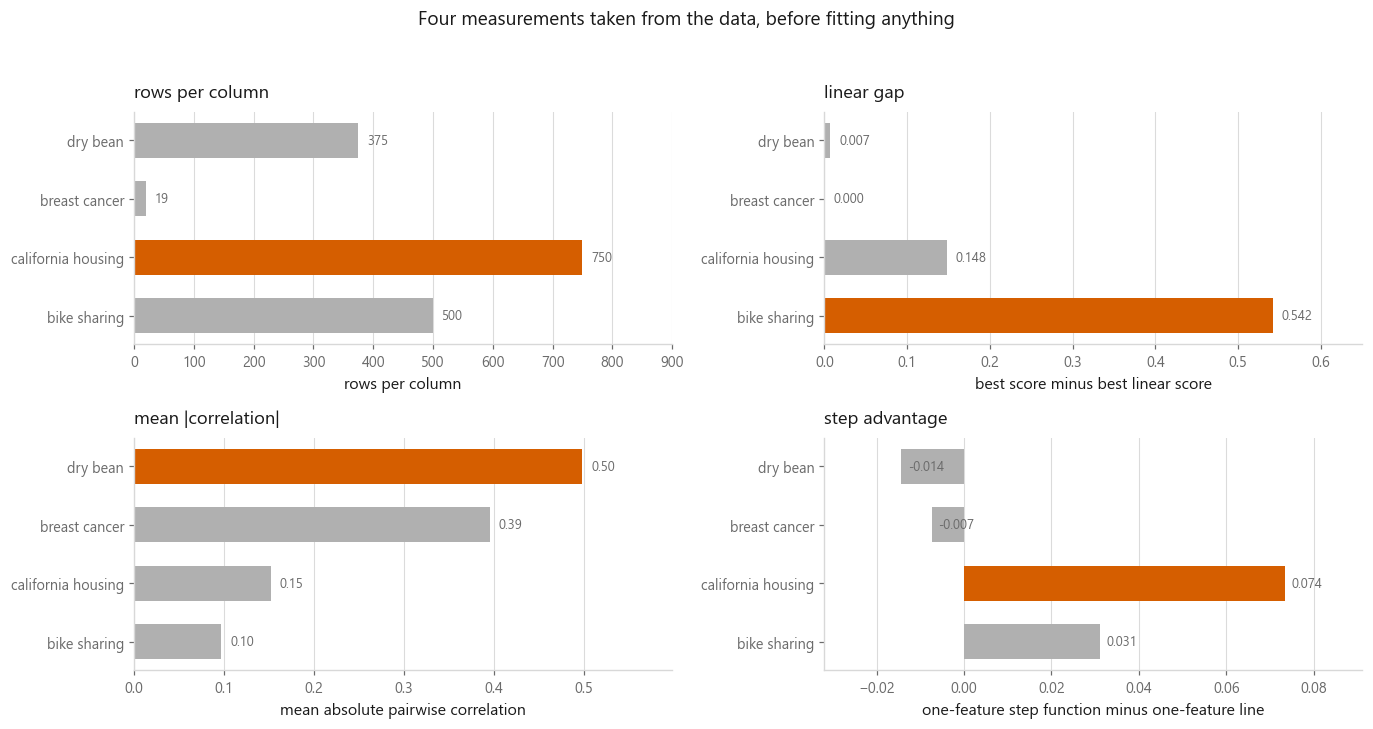

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 6.4))
order = list(traits.index)[::-1]      # barh draws bottom-up

panels = [("rows per column", "rows per column", "{:.0f}"),
          ("linear gap", "best score minus best linear score", "{:.3f}"),
          ("mean |correlation|", "mean absolute pairwise correlation", "{:.2f}"),
          ("step advantage", "one-feature step function minus one-feature line", "{:.3f}")]

for ax, (column, label, fmt) in zip(axes.ravel(), panels):
    values = traits.loc[order, column].astype(float)
    colours = style.spot(len(order), int(np.argmax(values.to_numpy())))
    ax.barh(order, values, color=colours, height=0.6)
    for i, v in enumerate(values):
        ax.text(v + values.max() * 0.02, i, fmt.format(v), va="center",
                fontsize=8.5, color=style.MUTED)
    ax.set_xlabel(label)
    ax.margins(x=0.2)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    style.title(ax, column)

fig.suptitle("Four measurements taken from the data, before fitting anything",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
fig.tight_layout()
style.save(fig, FIG / "fig-04-what-makes-them-different.png")

### Reading the four datasets

Now the connections, one dataset at a time. I wrote these as expectations before
running anything, and the cell after them checks each one against the numbers
rather than letting me quietly move the goalposts.

**Breast cancer** is the small one. It has the fewest rows against the most
columns of any dataset here, so I expect the worst rows-per-column ratio of the
four, and its columns repeat each other, because radius, perimeter and area of the
same cell nucleus are three names for one thing. Both facts point the same way:
a flexible model has very little data per direction to learn from, and a linear
boundary in a redundant thirty-dimensional space is already close to the best
available. I expect the linear gap here to be the smallest of the four, and I
expect the neural network to gain nothing over logistic regression.

**Dry bean** has plenty of rows, moderately redundant shape features, and seven
classes whose boundaries are curved rather than straight. Enough data for a
flexible model, so I expect the ensembles and the RBF SVM to lead, and the gap
over the linear models to be real but modest.

**California housing** has only eight columns but two of them are latitude and
longitude, and house prices as a function of latitude are not a slope; they are
a map. That is a threshold effect in the purest form, and it is invisible to a
linear model unless you engineer it. I expect a large step advantage and a large
linear gap.

**Bike sharing** is the extreme case, and it is extreme because of one column.
Hour of day is coded zero to twenty-three, and demand as a function of that
integer has two sharp peaks. A linear model asked to fit demand against hour
fits a nearly flat line through the middle of it. A tree cuts the hour column
either side of each peak and has it. I expect this dataset to have both the
largest step advantage and the largest linear gap of the four, and I expect the
distance between the tree family and the linear family to be the widest anywhere
in this notebook.

In [14]:
ENSEMBLES = {"random forest", "extra trees", "gradient boosting"}

winners = pd.concat([clf_score.idxmax(), reg_score.idxmax()])
fastest = {}
for task in TASKS:
    frame = results[results["dataset"] == task.name]
    fastest[task.name] = frame.loc[frame["fit_seconds"].idxmin(), "method"]

mlp_vs_logistic = (clf_score.loc["MLP (64, 32)", "breast cancer"]
                   - clf_score.loc["logistic regression", "breast cancer"])

expectations = [
    ("a tree ensemble wins on every dataset",
     set(winners) <= ENSEMBLES),
    ("breast cancer has the smallest linear gap",
     traits["linear gap"].idxmin() == "breast cancer"),
    ("bike sharing has the largest linear gap",
     traits["linear gap"].idxmax() == "bike sharing"),
    ("bike sharing has the largest step advantage",
     traits["step advantage"].idxmax() == "bike sharing"),
    ("breast cancer has the fewest rows per column",
     traits["rows per column"].idxmin() == "breast cancer"),
    ("the MLP gains nothing over logistic regression on breast cancer",
     mlp_vs_logistic <= 0),
    ("the winner is never also the fastest method",
     all(winners[t.name] != fastest[t.name] for t in TASKS)),
]

for claim, held in expectations:
    print(f"  [{'held' if held else 'DID NOT HOLD':^12}] {claim}")

print(f"\nMLP minus logistic regression on breast cancer: {mlp_vs_logistic:+.4f}"
      f"  (fold sd of each: "
      f"{clf_sd.loc['MLP (64, 32)', 'breast cancer']:.4f}, "
      f"{clf_sd.loc['logistic regression', 'breast cancer']:.4f})")

print("\nwinner and fastest, per dataset, with what the win costs")
for task in TASKS:
    frame = results[results["dataset"] == task.name].set_index("method")
    win_s = frame.loc[winners[task.name], "fit_seconds"]
    fast_s = frame.loc[fastest[task.name], "fit_seconds"]
    print(f"  {task.name:<19} winner {winners[task.name]:<20} {win_s:8.4f} s   "
          f"fastest {fastest[task.name]:<20} {fast_s:8.4f} s   "
          f"({win_s / max(fast_s, 1e-9):6.1f}x)")

  [DID NOT HOLD] a tree ensemble wins on every dataset
  [    held    ] breast cancer has the smallest linear gap
  [    held    ] bike sharing has the largest linear gap
  [DID NOT HOLD] bike sharing has the largest step advantage
  [    held    ] breast cancer has the fewest rows per column
  [    held    ] the MLP gains nothing over logistic regression on breast cancer
  [    held    ] the winner is never also the fastest method

MLP minus logistic regression on breast cancer: -0.0404  (fold sd of each: 0.0147, 0.0142)

winner and fastest, per dataset, with what the win costs
  dry bean            winner RBF SVM                0.2276 s   fastest k-NN (k=10)            0.0066 s   (  34.7x)
  breast cancer       winner logistic regression    0.0099 s   fastest k-NN (k=10)            0.0033 s   (   3.0x)
  california housing  winner gradient boosting      1.8617 s   fastest lasso                  0.0039 s   ( 480.0x)
  bike sharing        winner random forest          3.0679 s   fastes

Any line above reading "DID NOT HOLD" is more informative than the ones that
held, and I would rather leave it printed than rewrite the paragraph above it.

One of the lines that held deserves less credit than the word suggests. "The
winner is never also the fastest" is a claim about identity, not about size, and
on breast cancer both the winner and the fastest method fit in a time the timer
reports as zero to two decimal places. The ratio column is the honest version of
that check: on the two large datasets the win costs orders of magnitude, and on
the small one it costs nothing you could measure. A boolean claim that turns on a
millisecond is not a finding, and I would rather say so than count it as one of
five out of seven.

The MLP result on breast cancer is the opposite case, and worth separating from
it. The gap to logistic regression is several times the fold standard deviation
of either method, so that one is real. Breast cancer has the lowest rows per
column of the four by a wide margin, printed in the next section, and at that
ratio there is not enough data to fit two hidden layers. The model spends its
capacity on noise in the training folds. That is textbook bias and variance,
from [chapter
01-03](../../01-foundations/03-overfitting-and-underfitting/), showing up in a
comparison table rather than in a learning curve.

The step-advantage prediction is the one that failed on substance. I expected
bike sharing to reward step functions most and California housing beat it. The
reason is that step advantage is measured one column at a time, and bike
sharing's threshold lives in one column while California housing's is spread over
several. Latitude on its own already carries a step, because prices jump at the
coast and around the metropolitan areas, and so does longitude, and so does
median income. Bike sharing has one spectacular column and the rest are ordinary,
and the measurement averages over all of them. The measurement is doing what it
says on the tin. My prediction confused "has the sharpest threshold anywhere"
with "has the highest average threshold effect". The linear gap, which lets
features combine, ordered the two datasets the way I expected.

Both classification datasets come out slightly negative, which is the same
measurement being honest. A depth-limited tree on one monotone feature has to
approximate a smooth relationship with a handful of constant pieces, and a
logistic curve on the same feature does not. Where the relationship is a slope,
discretising it costs you something.

### The k-NN story, separately

One method deserves its own measurement, because its failure mode is the
clearest illustration of a dataset property mattering. k-nearest neighbours
works by Euclidean distance, and Euclidean distance degrades in two ways: when
columns multiply, every point becomes roughly equidistant from every other, and
when columns repeat each other, the repeated fact gets counted once per copy.
[Chapter 03-02](../../03-classification/02-k-nearest-neighbours/) builds both
failures deliberately.

Both of those are measured above. So here is how far k-NN sits below the winner
on each dataset, next to the column count and the redundancy.

In [15]:
knn_gap = {}
for task in TASKS:
    board = clf_score if task.kind == "classification" else reg_score
    knn_gap[task.name] = board[task.name].max() - board.loc["k-NN (k=10)", task.name]

knn = pd.DataFrame({
    "columns": traits["columns"],
    "columns for 95% variance": traits["columns for 95% variance"],
    "mean |correlation|": traits["mean |correlation|"].round(3),
    "k-NN gap to winner": pd.Series(knn_gap).round(4),
})
print(knn.to_string())
print(f"\ncorrelation between column count and k-NN's gap: "
      f"{np.corrcoef(knn['columns'].astype(float), knn['k-NN gap to winner'])[0, 1]:+.2f}")

                    columns  columns for 95% variance  mean |correlation|  k-NN gap to winner
dry bean               16.0                       5.0               0.498              0.0092
breast cancer          30.0                      10.0               0.395              0.0123
california housing      8.0                       6.0               0.152              0.0674
bike sharing           12.0                      10.0               0.097              0.3906

correlation between column count and k-NN's gap: -0.41


That correlation points the wrong way, and I am not going to claim the textbook
is wrong on the strength of four points. A correlation over four datasets has two
degrees of freedom and would flip on a fifth.

What the four points do say is that the dimension count is not the variable
doing the work here. The dataset with the most columns is the one where k-NN is
closest to the winner, and the dataset where k-NN loses by a mile has twelve. The
variable that separates them is whether Euclidean distance means anything.
Breast cancer's thirty columns are thirty measurements of the size and texture of
one nucleus, all on comparable scales after standardising, so two similar cells
really are close together. Bike sharing's columns are an hour index, a weekday
flag, a temperature and a humidity, and standardising them does not make one unit
of hour comparable to one unit of humidity. Worse, hour 23 and hour 0 are one
hour apart in the world and the furthest apart possible in the column.

Curse of dimensionality is the usual name for k-NN's problem and it is real, but
it needs many more than thirty columns to bite. What bites first, and bit here,
is a feature space where the metric is meaningless. Fix that with feature
engineering, not with a smaller k.

## 6. No free lunch, and what to actually do

"No free lunch" is a theorem with a precise statement and a much looser everyday
use. The everyday version is the one that matters here: no method is best
everywhere, so a table of one dataset tells you about that dataset.

The two scoreboards use different method lists, so to rank across all four at
once I take the six families that appear on both sides (a linear model, k-NN, a
single tree, a random forest, gradient boosting, and a small neural network)
and rank those six within each dataset. Then, for each family, its best rank and
its worst rank across the four.

A rank table is exactly the kind of object this chapter has been warning about,
because ranking is a function that turns any gap at all, including a gap of two
thousandths, into a whole place. So the cell after the ranks prints how many of
the six sit inside one pooled fold standard deviation of the top family on each
dataset. Wherever that count is large, the ranks in that column are a shuffle.

In [16]:
FAMILIES = {
    "linear model":      {"classification": "logistic regression", "regression": "ridge"},
    "k-NN":              {"classification": "k-NN (k=10)", "regression": "k-NN (k=10)"},
    "decision tree":     {"classification": "decision tree", "regression": "decision tree"},
    "random forest":     {"classification": "random forest", "regression": "random forest"},
    "gradient boosting": {"classification": "gradient boosting", "regression": "gradient boosting"},
    "neural net":        {"classification": "MLP (64, 32)", "regression": "MLP (64, 32)"},
}

family_score = pd.DataFrame(index=list(FAMILIES),
                            columns=[t.name for t in TASKS], dtype=float)
family_sd = family_score.copy()
for task in TASKS:
    board = clf_score if task.kind == "classification" else reg_score
    spread = clf_sd if task.kind == "classification" else reg_sd
    for family, mapping in FAMILIES.items():
        family_score.loc[family, task.name] = board.loc[mapping[task.kind], task.name]
        family_sd.loc[family, task.name] = spread.loc[mapping[task.kind], task.name]

family_rank = family_score.rank(ascending=False, axis=0, method="min").astype(int)

print("rank within each dataset, among these six families")
print(family_rank.to_string())
print("\nbest and worst rank across the four datasets")
for family in FAMILIES:
    row = family_rank.loc[family]
    print(f"  {family:<19} best #{row.min()}  worst #{row.max()}  "
          f"mean {row.mean():.2f}")

rank within each dataset, among these six families
                   dry bean  breast cancer  california housing  bike sharing
linear model              2              1                   5             6
k-NN                      4              2                   4             5
decision tree             6              6                   6             4
random forest             5              4                   2             1
gradient boosting         3              3                   1             3
neural net                1              5                   3             2

best and worst rank across the four datasets
  linear model        best #1  worst #6  mean 3.50
  k-NN                best #2  worst #5  mean 3.75
  decision tree       best #4  worst #6  mean 5.50
  random forest       best #1  worst #5  mean 3.00
  gradient boosting   best #1  worst #3  mean 2.50
  neural net          best #1  worst #5  mean 2.75


In [17]:
# How much of each rank column is real. A place that costs less than a fold
# standard deviation to gain is a place the next reshuffle of the folds gives back.
print("how separable the six families are, per dataset")
real = {}
for task in TASKS:
    column, sds = family_score[task.name], family_sd[task.name]
    lead = column.idxmax()
    pooled = np.sqrt((sds[lead] ** 2 + sds ** 2) / 2)
    ratio = (column.max() - column) / pooled
    tied = list(ratio[ratio < 1.0].index)
    real[task.name] = len(FAMILIES) - len(tied)
    print(f"  {task.name:<19} {len(tied)} of {len(FAMILIES)} tied with {lead}"
          f"  ->  {', '.join(tied)}")
    print(f"  {'':<19} gap to leader in pooled fold sds: "
          + ", ".join(f"{f} {ratio[f]:.1f}" for f in FAMILIES))

print("\nrank columns worth reading as an ordering (fewer than half tied): "
      + ", ".join(n for n, r in real.items() if r > len(FAMILIES) / 2))

how separable the six families are, per dataset
  dry bean            5 of 6 tied with neural net  ->  linear model, k-NN, random forest, gradient boosting, neural net
                      gap to leader in pooled fold sds: linear model 0.3, k-NN 0.6, decision tree 5.9, random forest 0.7, gradient boosting 0.3, neural net 0.0
  breast cancer       3 of 6 tied with linear model  ->  linear model, k-NN, gradient boosting
                      gap to leader in pooled fold sds: linear model 0.0, k-NN 0.8, decision tree 2.9, random forest 1.3, gradient boosting 0.9, neural net 2.8
  california housing  1 of 6 tied with gradient boosting  ->  gradient boosting
                      gap to leader in pooled fold sds: linear model 5.2, k-NN 5.5, decision tree 8.9, random forest 1.2, gradient boosting 0.0, neural net 1.2
  bike sharing        1 of 6 tied with random forest  ->  random forest
                      gap to leader in pooled fold sds: linear model 100.9, k-NN 55.4, decision tree 7.0,

widest swing : linear model moves 5 places
steadiest    : decision tree moves 2 places
any family top ranked on all four? no


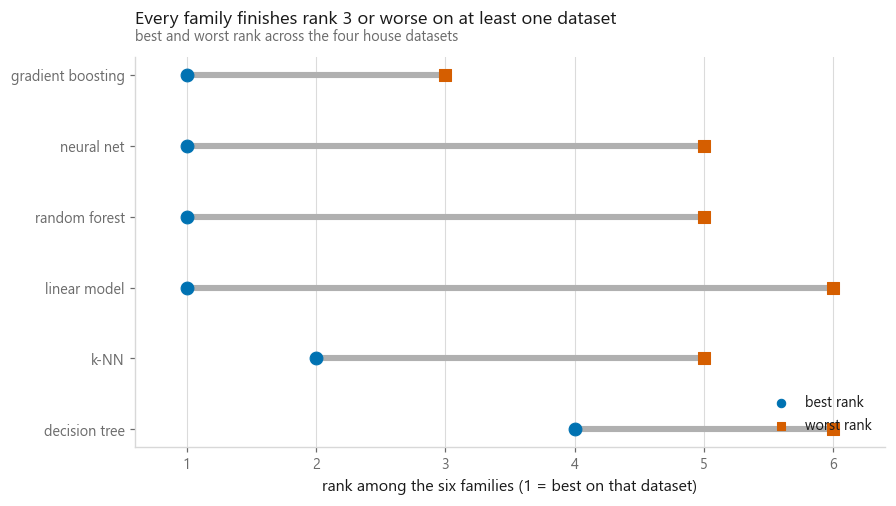

In [18]:
order = family_rank.mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8.8, 4.6))
for i, family in enumerate(order):
    low, high = family_rank.loc[family].min(), family_rank.loc[family].max()
    ax.plot([low, high], [i, i], color=style.NEUTRAL, lw=4,
            solid_capstyle="round", zorder=1)
    ax.scatter([low], [i], color=style.PALETTE[0], s=70, zorder=3,
               marker=style.MARKERS[0])
    ax.scatter([high], [i], color=style.HIGHLIGHT, s=70, zorder=3,
               marker=style.MARKERS[1])

ax.scatter([], [], color=style.PALETTE[0], marker=style.MARKERS[0], label="best rank")
ax.scatter([], [], color=style.HIGHLIGHT, marker=style.MARKERS[1], label="worst rank")
ax.legend(loc="lower right")

ax.set_yticks(range(len(order)), list(order))
ax.set_xticks(range(1, len(FAMILIES) + 1))
ax.set_xlim(0.6, len(FAMILIES) + 0.4)
ax.set_xlabel("rank among the six families (1 = best on that dataset)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
floor = int(family_rank.max(axis=1).min())
style.title(ax, f"Every family finishes rank {floor} or worse on at least one dataset",
            "best and worst rank across the four house datasets")
style.save(fig, FIG / "fig-05-no-free-lunch.png")

spread = (family_rank.max(axis=1) - family_rank.min(axis=1))
print(f"widest swing : {spread.idxmax()} moves {spread.max()} places")
print(f"steadiest    : {spread.idxmin()} moves {spread.min()} places")
print(f"any family top ranked on all four? "
      f"{'yes' if (family_rank == 1).all(axis=1).any() else 'no'}")

Two of those four rank columns survive the tie check and two do not, so read the
swing plot with the print above it open. On the two datasets where the top of the
column is one indistinguishable group, a family's rank there is close to a draw
from a hat, and the mean-rank number that averages all four columns inherits that
noise. I would not defend a difference of a quarter of a place between the top
three families.

What survives is coarser and more useful. The linear model moves from a group it
is a genuine member of, on breast cancer, to last by an enormous margin on bike
sharing, and that swing is far larger than any noise here. Gradient boosting is
never far from the leader on any of the four: it is inside the tie group where
there is one, first where there is not, and its one clear loss is to a random
forest and a neural network on bike sharing. That is a defensible argument for it
as a default, and notice that it is an argument about the worst case rather than
the best.

So the practical advice is not "always use gradient boosting". It is: measure the
four properties first and let them narrow the shortlist before you spend any
compute. Few rows relative to columns, start linear. A single feature carrying a
threshold, start with trees. Redundant columns or incommensurable units, be
careful with anything built on distance. And if your best linear model is inside
a fold standard deviation of your best ensemble, ship the linear one, because you
can explain it, it fits in a millisecond, and the ensemble did not actually beat
it.

## Cheat sheet

| Situation | Reach for | Why |
|---|---|---|
| The best method wins by less than the fold-to-fold spread | The cheaper method | It did not win. This is the first row for a reason |
| Fewer than about 30 rows per column | [Ridge](../../02-regression/04-ridge-regression/) or [logistic regression](../../03-classification/01-logistic-regression/) | A flexible model has nothing to learn from. Regularised linear is the honest default |
| Thousands of rows, tabular, mixed feature types | [Gradient boosting](../../04-ensembles/05-gradient-boosting/), then a [random forest](../../04-ensembles/02-random-forest/) | Splits handle thresholds and interactions with no feature engineering, and the scale of the columns is irrelevant |
| You need a baseline in one line | Ridge, or a random forest with defaults | Both take seconds. Anything that cannot beat them is not worth deploying |
| Columns are heavily correlated | Ridge, [PCA](../../06-dimensionality-reduction/01-principal-component-analysis/) first, or trees | Avoid raw distance methods. A fact measured three times votes three times in a Euclidean distance |
| Many columns, few of them useful | [Lasso](../../02-regression/05-lasso-regression/), or a tree ensemble with feature importance | Both do selection; the lasso does it explicitly. Tune the penalty, or it will cut signal, as it did here |
| A feature with sharp thresholds (hour, latitude, an ID band) | [Trees](../../03-classification/06-decision-trees/), or bin the feature before a linear model | A slope cannot represent a step. This is the single largest source of linear-model failure in this notebook |
| Smooth, low-dimensional, plenty of data | [RBF SVM](../../03-classification/05-support-vector-machines/) or [k-NN](../../03-classification/02-k-nearest-neighbours/) | Both are excellent when distance is meaningful, and both fall apart when it is not |
| You have to explain the model to a person | Linear model, or a shallow tree | Coefficients and split points are explainable. An ensemble of 150 trees needs [interpretation tooling](../02-interpreting-models/) |
| Unstructured data: images, text, audio | A neural network | Nothing in the table above applies. See [Part 8](../../08-computer-vision/) and [Part 9](../../09-sequences-and-language/) |

## What to remember

1. Check the gap against the fold-to-fold standard deviation before you believe
   it. On both classification datasets here, the top of the column is one group
   that the experiment cannot order, and a heatmap will happily paint ranks on it
   anyway.
2. Do not divide the fold standard deviation by the square root of the fold
   count. Folds share training rows, their scores are correlated, and that
   standard error comes out too small.
3. A comparison table is only worth reading if every cell came out of the same
   function. One harness, one set of folds, one scaling rule, one seed.
4. Which family wins is a property of the dataset, not of the family, and the
   properties that decide it are measurable before you fit anything.
5. Few rows per column and a linear model is not a compromise, it is the right
   answer. The MLP lost to logistic regression here by several fold standard
   deviations for exactly that reason.
6. Threshold features are why trees beat linear models on tabular data far more
   often than curvature is. An hour-of-day column is worth more to a tree than
   a hundred extra rows.
7. Report time next to score. A win inside the noise bought with fifty times the
   compute is worse than no win, because you now have to maintain it.
8. A hyperparameter default is not a property of a method. Lasso finished last on
   California housing at an alpha that would be reasonable elsewhere.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [12-02 Interpreting models](../02-interpreting-models/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#ModelSelection` `#NoFreeLunch` `#Benchmarking`
`#GradientBoosting` `#ScikitLearn` `#Python` `#DataScience` `#MLTutorial`
`#CrossValidation`